# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()

# Replace the following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.plot import Plot
from frank2d.constants import rad_to_arcsec

# frank1d
from frank.utilities import UVDataBinner

# Data

In [5]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}

In [6]:
data = AS209

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
r_out = data['rout']

In [7]:
# Frank Parameters
N = 300
 # load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

# Calculate log posterior with F1D approach
Considerations:
- Is important to remember that we are using F1D framework to do this, this is, directly solving I = Dj. For this, I use the module posterior_optimization.py, which contains the necessary functions from Frank1D to do so. We use only GaussianProcess class.
- Because this framework process all the visibility input, we give it directly gridded visibilities.

In [8]:
# Create a (u, v, Vis, Weights) based on Frank2D Gridding.
N = 300
geom = Geometry(inc, pa, dra, ddec)
frank2d_ = Frank2D(N, r_out, geom)
frank2d_.process_vis(u, v, Vis, Weights)

data =  frank2d_.gridded_data
u_, v_, Vis_, Weights_ = data["u"], data["v"], data["vis"], data["weights"]

Shifted grid..
Setting gridded data...


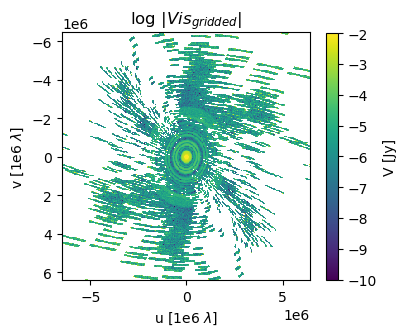

In [9]:
# Let's review the gridded visibilities first.
u_s, v_s = u_.reshape(N, N),v_.reshape(N, N)
vis_s = Vis_.reshape(N, N)

plt.figure(figsize= (4, 4))
plt.pcolormesh(u_s,
               v_s,
               np.log(np.abs(vis_s)),
               cmap="viridis", vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{gridded}$|')
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'V [Jy]', size=10)
plt.gca().invert_yaxis()
plt.gca().set_aspect(1)
plt.show()

In [10]:
# Let's review the power spectrum.
baselines = np.hypot(u_, v_)         
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths=[1e3, 1e5]

binned_vis = UVDataBinner(baselines, Vis_, Weights_, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis_, Weights_, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)
    
m_array = np.array([-2, -3, -4, -6])
logc_array = np.array([8, 13, 18, 30])
c_array = 10**logc_array

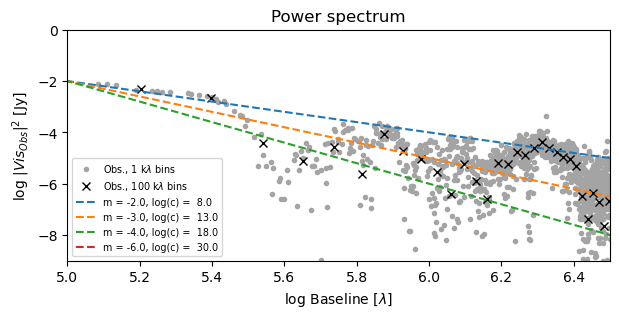

In [11]:
plt.figure(figsize=(7, 3))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

for i in range(0, len(m_array)):
    plt.plot(logx2, linear_power_spectrum(logx2, m_array[i], c_array[i]), ls = '--', label = f'm = {m_array[i]: .1f}, log(c) = {logc_array[i]: .1f}')

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
plt.ylim(-9, 0)
plt.xlim(5, 6.5)
plt.show()

### Optimization

In [12]:
# The amount of collocation points is less.
N_f1d = 50

In [13]:
import time
start_time = time.time()
FF = FourierBesselFitter(r_out, N_f1d, geom)
sol = FF.fit(u_, v_, Vis_, Weights_)
total_time = time.time() - start_time
print("--- %s minutes ---", total_time/60, " minutes.")

--- %s minutes --- 1.7287594159444173  minutes.


In [14]:
# In this object is everything.
GM = FF._GaussianModel
FT = GM._DFT

## MAP value

### e.g emcee run

In [15]:
os.environ["OMP_NUM_THREADS"] = "4" #pool

In [16]:
# this is a dummy run with steps = 10.

In [17]:
GM.optimize_posterior(method="emcee")

....................................OPTIMIZING.................................. 
 ---> Initial parameters: m, logc, logl: -2 8 4.845098040014257
 ---> Bounds for m, logc, logl: (-6, -1.9) (7, 30) (5, 6.5)
Using emcee for optimization


AttributeError: Can't pickle local object 'GaussianModel.emcee_optimizer.<locals>.log_prob_rep'

In [ ]:
samples = GM.samples
logp = GM.samples_logp

In [ ]:
m = samples[:, 0]
logc = samples[:, 1]
logl = samples[:, 2]
logp = logp

imax = np.argmax(logp)

In [ ]:
plt.figure(figsize=(5.2, 4.4))
sc = plt.scatter(m, logc, c=logp, s=10, alpha=0.7, cmap="viridis")
plt.plot(m[imax], logc[imax], marker="*", ms=15, color="red", label="MAP")
plt.colorbar(sc, label=r"$\log P(\theta|X)$")
plt.xlabel(r"$m$")
plt.ylabel(r"$\log_{10} c$")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(7, 5), sharey=True)
axs[0].scatter(m, logp, s=6, alpha=0.5)
axs[0].set_xlabel(r"$m$")
axs[0].set_ylabel(r"$\log P$")
axs[0].plot(m[imax], logp[imax], marker="*", ms=15, color="red", label="MAP")


axs[1].set_ylabel(r"$\log P$")
axs[1].scatter(logc, logp, s=6, alpha=0.5)
axs[1].plot(logc[imax], logp[imax], marker="*", ms=15, color="red", label="MAP")
axs[1].set_xlabel(r"$\log_{10} c$")


axs[2].set_ylabel(r"$\log P$")
axs[2].scatter(logl, logp, s=6, alpha=0.5)
axs[2].plot(logl[imax], logp[imax], marker="*", ms=15, color="red", label="MAP")
axs[2].set_xlabel(r"$\log_{10} l$")

plt.tight_layout(); plt.show()

In [ ]:
import corner
flat_samples = GM.samples

corner.corner(
    flat_samples,
    labels=[r"$m$", r"$\log_{10} c$", r"$\log_{10} l$" ],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    bins=20
)
plt.show()

In [ ]:
m_best, log_c_best, logl_best = GM._best
GM.one_fit({"m":m_best, "logc": logc_best, "logl": logl_best})

In [ ]:
fig.suptitle(f' m = {m_best:.2f}, $log(c) $ =  {logc_best:.2f}, $log(l) $ =  {logl_best:.2f} (N = ' + str(N) + ')' , fontsize=10)

# Plot the solution.

# Let's review the gridded visibilities first.
shape_f1d = (N_f1d, N_f1d)
u_f1d = FT._u_shifted.max()
v_f1d = FT._v_shifted.max()

I_f1d = GM.sol.reshape(shape_f1d).real
V_f1d = np.fft.fftshift(np.fft.ifft2(I_f1d))

plt.figure(figsize = (4, 4))

fig, axs = plt.subplots(1, 2, figsize=(9, 9))
axs = axs.ravel()

im0 = axs[0].imshow(np.log(np.abs(V_f1d) + 1e-12),  # evita log(0)
                    extent=[-u_f1d, u_f1d, -v_f1d, v_f1d],
                    cmap="magma")
axs[0].set_xlabel(r'u [1e6 $\lambda$]')
axs[0].set_ylabel(r'v [1e6 $\lambda$]')
axs[0].set_title(r'$\log\,|Vis_{Model}|$')
cbar0 = fig.colorbar(im0, ax=axs[0], shrink=0.3)
cbar0.set_label(r'V [Jy]', size=10)
axs[0].set_aspect('equal')

# Panel 2
im1 = axs[1].imshow(I_f1d,
                    extent=[-r_out, r_out, -r_out, r_out],
                    cmap="magma")
axs[1].set_xlabel(r'x ["]')
axs[1].set_ylabel(r'y ["]')
axs[1].set_title(r'$I_{Model}$')
cbar1 = fig.colorbar(im1, ax=axs[1], shrink=0.3)
cbar1.set_label(r'I [Jy/sr]', size=10)
axs[1].set_aspect('equal')

plt.tight_layout()